# EGNN reconstruction-signal exploration

This compact notebook investigates why the reconstruction-driven liquid–FCC EGNN uses an almost one-dimensional latent and why four different decoder targets give similar probe accuracy.

The previous result contains two distinct observations:

1. **The two coordinates are almost perfectly correlated.** Across 30 seeds, effective rank was approximately 1.00–1.01. A nonlinear decoder can map a curved one-dimensional code to many output dimensions, so reconstruction alone does not guarantee that both latent coordinates are used.
2. **Most targets were barely learned.** Standardized validation losses for center distances, vectors, and $q_l$ quickly plateaued near their constant-prediction baselines. Pairwise-distance loss decreased substantially, especially for 18 neighbors. The similar absolute probe scores therefore do not mean that all four reconstructions worked equally well. They suggest that the shared graph encoder itself exposes a liquid–FCC statistic, even when the reconstruction gradient changes it very little.

Raw vectors are a deliberate negative control. The encoder is rotation invariant, whereas the flattened vector target changes under rotation. Its optimal invariant prediction is close to a conditional mean, often nearly zero. Once the decoder reaches that mean, the expected gradient carrying structural information back to the encoder is weak. Consequently, **poor vector reconstruction is expected, but poor reconstruction does not mathematically require chance-level probe accuracy**: an untrained or weakly trained distance-based graph encoder may already separate the phases.

This notebook tests a small architectural ladder while keeping phase labels out of training. Every model has a native two-dimensional latent and uses reconstruction as its only optimized objective. It reports:

- reconstruction skill relative to a constant training-mean decoder;
- balanced accuracy before and after reconstruction training;
- the probe improvement caused by training;
- encoder parameter displacement and first-step gradient norms;
- latent effective rank;
- linear CKA between latents trained on different targets;
- an optional shuffled-target control.

The aim is not to force a visually round cloud. A promising configuration should reconstruct real targets better than the constant and shuffled controls, change the encoder measurably, improve the probe relative to the identical untrained encoder, and show target-dependent latent representations. The 18-neighbor result should improve without a shell-dependent change in message scale.

In [1]:
import gc
import os
import random
import warnings
from copy import deepcopy
from dataclasses import dataclass, asdict
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


PHASES = ("liquid", "fcc")
LABELS = {"liquid": 0, "fcc": 1}
COLORS = {0: "tab:green", 1: "tab:blue"}
SHELLS = {
    "first_shell": {
        "label": "1 shell (12 NN)",
        "n_neighbors": 12,
        "filenames": ("particle_data.npz",),
        "ql_key": "ql_no_average",
        "ql_variant": "standard",
    },
    "second_shell": {
        "label": "2 shells (18 NN)",
        "n_neighbors": 18,
        "filenames": (
            "particle_data_second_shell_nn18_ql18.npz",
            "particle_data_second_shell.npz",
        ),
        "ql_key": "ql",
        "ql_variant": "Lechner–Dellago averaged",
    },
}
TARGETS = ("radii", "pairwise", "vectors", "ql")
TARGET_LABELS = {
    "radii": "Center distances",
    "pairwise": "Pairwise distances",
    "vectors": "Neighbor vectors",
    "ql": r"$q_l$",
}

# The default screen is deliberately small. Increase these only after reading
# the one-seed diagnostics. Confirmation repeats the same screen for 3 seeds.
SCREEN_SEEDS = (42,)
CONFIRMATION_SEEDS = (42, 7, 19)
RUN_CONFIRMATION = False
MAX_SAMPLES_PER_PHASE = 1_000
BATCH_SIZE = 256
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-6
MIN_OPTIMIZER_STEPS = 800
MAX_OPTIMIZER_STEPS = 1_200
VALIDATE_EVERY_STEPS = 50
PATIENCE_CHECKS = 5
FEATURE_DIM = 48
MESSAGE_DIM = 48
N_LAYERS = 2
COORDINATE_UPDATE_SCALE = 0.05
LATENT_DIM = 2
VAL_FRACTION = 0.20
TEST_FRACTION = 0.20
PLOT_SPEC = "center_rbf_mlp_mse"
RUN_ARCHITECTURE_SCREEN = False
RUN_SHUFFLED_TARGET_CONTROL = False
RUN_SMALL_THREE_CLASS_SCREEN = False
RUN_FULL_DATASET_PCA_EGNN = True
SHUFFLE_CONTROL_SHELL = "second_shell"

if os.environ.get("AE_SMOKE_TEST") == "1":
    SCREEN_SEEDS = (42,)
    CONFIRMATION_SEEDS = (42,)
    RUN_CONFIRMATION = False
    MAX_SAMPLES_PER_PHASE = 96
    BATCH_SIZE = 32
    FEATURE_DIM = 12
    MESSAGE_DIM = 12
    MIN_OPTIMIZER_STEPS = 4
    MAX_OPTIMIZER_STEPS = 6
    VALIDATE_EVERY_STEPS = 2
    PATIENCE_CHECKS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR_CANDIDATES = (
    Path("."),
    Path("lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
    Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
)
DATA_DIR = next(
    (
        candidate
        for candidate in DATA_DIR_CANDIDATES
        if all((candidate / phase / "particle_data.npz").exists() for phase in PHASES)
    ),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Run this notebook from its directory or the repository root.")

print("Data:", DATA_DIR.resolve())
print("Device:", DEVICE)
print("Screen seeds:", SCREEN_SEEDS)
print("Samples per phase:", MAX_SAMPLES_PER_PHASE)
print("Optimizer steps:", MIN_OPTIMIZER_STEPS, "to", MAX_OPTIMIZER_STEPS)

Data: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
Device: cuda
Screen seeds: (42,)
Samples per phase: 1000
Optimizer steps: 800 to 1200


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def scalar(npz, key, default=None):
    if key not in npz.files:
        return default
    value = np.asarray(npz[key])
    return value.item() if value.shape == () else value.tolist()


def resolve_file(phase, shell):
    for filename in SHELLS[shell]["filenames"]:
        path = DATA_DIR / phase / filename
        if path.exists():
            return path
    raise FileNotFoundError(f"No input file for {phase}/{shell}")


def load_phase_shell(phase, shell):
    config = SHELLS[shell]
    path = resolve_file(phase, shell)
    with np.load(path, allow_pickle=True) as npz:
        distances = np.asarray(npz["dist"], dtype=np.float32)
        vectors = np.asarray(npz["vec_dist"], dtype=np.float32)
        if vectors.ndim == 2:
            vectors = vectors.reshape(len(vectors), -1, 3)
        data = {
            "dist": distances,
            "vectors": vectors,
            "ql": np.asarray(npz[config["ql_key"]], dtype=np.float32),
            "picked_ids": np.asarray(npz["picked_ids"]),
            "frame_indices": np.asarray(npz["frame_indices"]),
            "descriptor_nn": int(
                scalar(npz, "descriptor_nn", scalar(npz, "nn", vectors.shape[1]))
            ),
            "source": path,
        }
    order = np.argsort(data["dist"], axis=1)
    data["dist"] = np.take_along_axis(data["dist"], order, axis=1)
    data["vectors"] = np.take_along_axis(
        data["vectors"], order[:, :, None], axis=1
    )
    if data["vectors"].shape[1] != config["n_neighbors"]:
        raise ValueError(f"Unexpected neighbor count in {path}")
    return data


DATA = {
    shell: {phase: load_phase_shell(phase, shell) for phase in PHASES}
    for shell in SHELLS
}
for phase in PHASES:
    if not np.array_equal(
        DATA["first_shell"][phase]["picked_ids"],
        DATA["second_shell"][phase]["picked_ids"],
    ):
        raise ValueError(f"Shell particle IDs are not paired for {phase}.")
for phase in PHASES:
    second = DATA["second_shell"][phase]
    if second["descriptor_nn"] != SHELLS["second_shell"]["n_neighbors"]:
        warnings.warn(
            f"{phase}: stored averaged q_l uses {second['descriptor_nn']} neighbors, not 18."
        )


def frame_split(frame_indices, rng):
    frames = rng.permutation(np.unique(frame_indices))
    n_test = max(1, round(TEST_FRACTION * len(frames)))
    n_val = max(1, round(VAL_FRACTION * len(frames)))
    split = np.full(len(frame_indices), "train", dtype="<U5")
    split[np.isin(frame_indices, frames[:n_test])] = "test"
    split[np.isin(frame_indices, frames[n_test:n_test + n_val])] = "val"
    return split


def sampling_plan(seed):
    rng = np.random.default_rng(seed)
    count = min(
        MAX_SAMPLES_PER_PHASE,
        *(len(DATA["first_shell"][phase]["dist"]) for phase in PHASES),
    )
    plan = {}
    for phase in PHASES:
        reference = DATA["first_shell"][phase]
        indices = np.sort(rng.choice(len(reference["dist"]), count, replace=False))
        plan[phase] = {
            "indices": indices,
            "split": frame_split(reference["frame_indices"][indices], rng),
        }
    return plan


def pairwise_features(vectors, chunk_size=1024):
    n_samples, n_neighbors, _ = vectors.shape
    left, right = np.triu_indices(n_neighbors + 1, k=1)
    output = np.empty((n_samples, len(left)), dtype=np.float32)
    for start in range(0, n_samples, chunk_size):
        stop = min(start + chunk_size, n_samples)
        points = np.concatenate(
            [np.zeros((stop - start, 1, 3), np.float32), vectors[start:stop]],
            axis=1,
        )
        output[start:stop] = np.linalg.norm(
            points[:, left, :] - points[:, right, :], axis=-1
        )
    output.sort(axis=1)
    return output


def target_array(data, target, indices):
    if target == "radii":
        return data["dist"][indices].copy()
    if target == "pairwise":
        return pairwise_features(data["vectors"][indices])
    if target == "vectors":
        return data["vectors"][indices].reshape(len(indices), -1).copy()
    if target == "ql":
        return data["ql"][indices].copy()
    raise KeyError(target)


def prepare(shell, target, plan):
    coordinate_parts, target_parts, label_parts, split_parts = [], [], [], []
    for phase in PHASES:
        entry = plan[phase]
        data = DATA[shell][phase]
        neighbors = data["vectors"][entry["indices"]]
        coordinates = np.concatenate(
            [np.zeros((len(neighbors), 1, 3), np.float32), neighbors], axis=1
        )
        coordinate_parts.append(coordinates)
        target_parts.append(target_array(data, target, entry["indices"]))
        label_parts.append(np.full(len(neighbors), LABELS[phase], np.int64))
        split_parts.append(entry["split"])
    return (
        np.concatenate(coordinate_parts).astype(np.float32),
        np.concatenate(target_parts).astype(np.float32),
        np.concatenate(label_parts),
        np.concatenate(split_parts),
    )


display(pd.DataFrame([
    {
        "shell": SHELLS[shell]["label"],
        "phase": phase,
        "samples": len(DATA[shell][phase]["dist"]),
        "nodes_with_center": SHELLS[shell]["n_neighbors"] + 1,
        "q_l_descriptor_NN": DATA[shell][phase]["descriptor_nn"],
    }
    for shell in SHELLS for phase in PHASES
]))

/tmp/ipykernel_51506/3049525480.py:66: UserWarning: liquid: stored averaged q_l uses 12 neighbors, not 18.
  warnings.warn(
/tmp/ipykernel_51506/3049525480.py:66: UserWarning: fcc: stored averaged q_l uses 12 neighbors, not 18.
  warnings.warn(


,shell,phase,samples,nodes_with_center,q_l_descriptor_NN
0,1 shell (12 NN),liquid,90300,13,12
1,1 shell (12 NN),fcc,180300,13,12
2,2 shells (18 NN),liquid,90300,19,12
3,2 shells (18 NN),fcc,180300,19,12


## Is a two-dimensional reconstruction even sufficient?

Before training an EGNN, PCA reconstructs each standardized target directly from two components. This is not a deployable graph model; it is a target-space reference. Its test reconstruction skill estimates what a **linear two-dimensional bottleneck with direct access to the answer** can achieve. If this value is near zero, expecting the graph encoder plus a linear decoder to reconstruct that target well is unrealistic. A nonlinear decoder may exceed this linear reference when the target lies on a curved low-dimensional manifold.

In [3]:
oracle_plan = sampling_plan(SCREEN_SEEDS[0])
oracle_rows = []
for shell in SHELLS:
    for target in TARGETS:
        _, values, _, split = prepare(shell, target, oracle_plan)
        train = split == "train"
        test = split == "test"
        scaler = StandardScaler().fit(values[train])
        scaled = scaler.transform(values)
        pca = PCA(n_components=2, random_state=SCREEN_SEEDS[0]).fit(scaled[train])
        reconstruction = pca.inverse_transform(pca.transform(scaled[test]))
        test_mse = float(np.mean((reconstruction - scaled[test]) ** 2))
        constant_mse = float(np.mean(scaled[test] ** 2))
        oracle_rows.append({
            "shell": shell,
            "shell_label": SHELLS[shell]["label"],
            "target": target,
            "target_label": TARGET_LABELS[target],
            "target_dimension": values.shape[1],
            "PCA_2D_reconstruction_skill": 1.0 - test_mse / constant_mse,
            "PCA_2D_explained_variance_train": float(pca.explained_variance_ratio_.sum()),
        })
target_pca_oracle = pd.DataFrame(oracle_rows)
display(target_pca_oracle.round(4))

,shell,shell_label,target,target_label,target_dimension,PCA_2D_reconstruction_skill,PCA_2D_explained_variance_train
0,first_shell,1 shell (12 NN),radii,Center distances,12,0.6944,0.6930
1,first_shell,1 shell (12 NN),pairwise,Pairwise distances,78,0.7748,0.8092
2,first_shell,1 shell (12 NN),vectors,Neighbor vectors,36,0.0612,0.0804
3,first_shell,1 shell (12 NN),ql,$q_l$,20,0.5420,0.5430
4,second_shell,2 shells (18 NN),radii,Center distances,18,0.5243,0.5133
5,second_shell,2 shells (18 NN),pairwise,Pairwise distances,171,0.8383,0.8373
6,second_shell,2 shells (18 NN),vectors,Neighbor vectors,54,0.0508,0.0624
7,second_shell,2 shells (18 NN),ql,$q_l$,20,0.6489,0.6525


## Reconstruction-only model ladder

The first screen showed that 35 epochs on 800 samples meant only about 140 optimizer updates—less than one third of the earlier benchmark—and no model beat the constant decoder. This round trains by **optimizer step**, not epoch, and does not allow early stopping before 800 updates.

Four non-redundant configurations remain:

- `mean_mlp_mse` is the reconstruction-only mean-pooling reference. Smooth-L1 is removed because it did not improve the first screen and gives weaker pressure to explain standardized variance.
- `center_mlp_mse` explicitly marks the central node and reads out the center state plus neighbor mean and standard deviation.
- `center_rbf_mlp_mse` additionally expands distances into radial basis functions, which should help resolve the broader 18-neighbor distance range.
- `center_rbf_linear_mse` keeps the RBF encoder but constrains the decoder to be linear. A nonlinear decoder can map a one-dimensional curve to many outputs; a linear decoder must use a second direction whenever it reduces reconstruction error.

The constant training-mean decoder is used only as an evaluation baseline. An earlier draft initialized the decoder output weights to exactly zero, but that created a dead equilibrium: standardized targets have zero mean, so an almost constant latent supplied almost no target-correlated gradient to the decoder, and the zero decoder supplied no useful gradient to the encoder. The output layer now uses a small nonzero Xavier initialization with zero bias. It starts close to the constant baseline while preserving a reconstruction-gradient path. `first_encoder_gradient` below is the largest encoder gradient observed during the first 50 updates.

There is still no latent variance, correlation, contrastive, or classification term. Both latent coordinates must justify themselves through reconstruction.

In [4]:
@dataclass(frozen=True)
class ModelSpec:
    name: str
    loss: str = "mse"
    center_aware: bool = False
    readout: str = "mean"
    decoder: str = "mlp"
    edge_encoding: str = "raw"


SPECS = (
    ModelSpec("mean_mlp_mse"),
    ModelSpec("center_mlp_mse", center_aware=True, readout="center_stats"),
    ModelSpec(
        "center_rbf_mlp_mse",
        center_aware=True,
        readout="center_stats",
        edge_encoding="rbf",
    ),
    ModelSpec(
        "center_rbf_linear_mse",
        center_aware=True,
        readout="center_stats",
        decoder="linear",
        edge_encoding="rbf",
    ),
)
SPEC_BY_NAME = {spec.name: spec for spec in SPECS}
display(pd.DataFrame([asdict(spec) for spec in SPECS]))


class MLP(nn.Module):
    def __init__(self, dimensions):
        super().__init__()
        layers = []
        for index in range(len(dimensions) - 1):
            layers.append(nn.Linear(dimensions[index], dimensions[index + 1]))
            if index < len(dimensions) - 2:
                layers.append(nn.SiLU())
        self.network = nn.Sequential(*layers)

    def forward(self, values):
        return self.network(values)


class RadialBasis(nn.Module):
    def __init__(self, count=16, maximum=3.5):
        super().__init__()
        centers = torch.linspace(0.0, maximum, count)
        spacing = float(centers[1] - centers[0])
        self.register_buffer("centers", centers)
        self.gamma = 1.0 / spacing**2

    def forward(self, distance):
        return torch.exp(-self.gamma * (distance - self.centers).square())


class EGNNLayer(nn.Module):
    def __init__(self, edge_encoding):
        super().__init__()
        self.edge_encoding = edge_encoding
        self.rbf = RadialBasis() if edge_encoding == "rbf" else None
        edge_dim = len(self.rbf.centers) if self.rbf is not None else 1
        self.edge_mlp = MLP(
            [2 * FEATURE_DIM + edge_dim, MESSAGE_DIM, MESSAGE_DIM, MESSAGE_DIM]
        )
        self.coordinate_mlp = MLP([MESSAGE_DIM, MESSAGE_DIM, 1])
        self.node_mlp = MLP([FEATURE_DIM + MESSAGE_DIM, FEATURE_DIM, FEATURE_DIM])

    def forward(self, features, coordinates, edge_index):
        receivers, senders = edge_index
        relative = coordinates[:, receivers] - coordinates[:, senders]
        squared_distance = relative.square().sum(dim=-1, keepdim=True)
        if self.rbf is None:
            edge_features = squared_distance
        else:
            edge_features = self.rbf(torch.sqrt(squared_distance + 1e-8))
        messages = self.edge_mlp(
            torch.cat(
                [features[:, receivers], features[:, senders], edge_features],
                dim=-1,
            )
        )
        n_nodes = coordinates.shape[1]
        degree = torch.bincount(receivers, minlength=n_nodes).clamp_min(1)
        degree = degree.to(coordinates.dtype).view(1, n_nodes, 1)

        coordinate_weight = torch.tanh(self.coordinate_mlp(messages))
        coordinate_update = torch.zeros_like(coordinates)
        coordinate_update.index_add_(1, receivers, relative * coordinate_weight)
        coordinates = (
            coordinates
            + COORDINATE_UPDATE_SCALE * coordinate_update / degree
        )

        aggregated = torch.zeros(
            features.shape[0], n_nodes, MESSAGE_DIM,
            device=features.device, dtype=features.dtype,
        )
        aggregated.index_add_(1, receivers, messages)
        features = features + self.node_mlp(
            torch.cat([features, aggregated / degree], dim=-1)
        )
        return features, coordinates


class GraphEncoder(nn.Module):
    def __init__(self, spec):
        super().__init__()
        self.spec = spec
        input_dim = 2 if spec.center_aware else 1
        self.embedding = MLP([input_dim, FEATURE_DIM, FEATURE_DIM])
        self.layers = nn.ModuleList(
            [EGNNLayer(spec.edge_encoding) for _ in range(N_LAYERS)]
        )
        readout_dim = 3 * FEATURE_DIM if spec.readout == "center_stats" else FEATURE_DIM
        self.to_latent = MLP([readout_dim, FEATURE_DIM, FEATURE_DIM, LATENT_DIM])

    def forward(self, coordinates, edge_index):
        batch_size, n_nodes, _ = coordinates.shape
        ones = torch.ones(
            batch_size, n_nodes, 1,
            device=coordinates.device, dtype=coordinates.dtype,
        )
        if self.spec.center_aware:
            center_marker = torch.zeros_like(ones)
            center_marker[:, 0] = 1.0
            node_input = torch.cat([ones, center_marker], dim=-1)
        else:
            node_input = ones
        features = self.embedding(node_input)
        updated_coordinates = coordinates
        for layer in self.layers:
            features, updated_coordinates = layer(
                features, updated_coordinates, edge_index
            )
        if self.spec.readout == "mean":
            graph_features = features.mean(dim=1)
        else:
            neighbors = features[:, 1:]
            graph_features = torch.cat(
                [
                    features[:, 0],
                    neighbors.mean(dim=1),
                    neighbors.std(dim=1, unbiased=False),
                ],
                dim=-1,
            )
        return self.to_latent(graph_features)


class GraphAutoencoder(nn.Module):
    def __init__(self, spec, output_dim):
        super().__init__()
        self.encoder = GraphEncoder(spec)
        if spec.decoder == "linear":
            self.decoder = nn.Linear(LATENT_DIM, output_dim)
            output_layer = self.decoder
        else:
            self.decoder = MLP(
                [LATENT_DIM, FEATURE_DIM, FEATURE_DIM, FEATURE_DIM, output_dim]
            )
            output_layer = self.decoder.network[-1]

        # Zero bias is the standardized target mean, but nonzero weights are
        # essential: exact zero weights disconnect reconstruction from the encoder.
        nn.init.xavier_uniform_(output_layer.weight, gain=0.5)
        nn.init.zeros_(output_layer.bias)

    def forward(self, coordinates, edge_index):
        latent = self.encoder(coordinates, edge_index)
        return self.decoder(latent), latent


def complete_edges(n_nodes):
    receiver, sender = np.where(~np.eye(n_nodes, dtype=bool))
    return torch.tensor(np.stack([receiver, sender]), dtype=torch.long)


def reconstruction_loss(prediction, target, kind):
    if kind == "smooth_l1":
        return nn.functional.smooth_l1_loss(prediction, target)
    return nn.functional.mse_loss(prediction, target)

,name,loss,center_aware,readout,decoder,edge_encoding
0,mean_mlp_mse,mse,False,mean,mlp,raw
1,center_mlp_mse,mse,True,center_stats,mlp,raw
2,center_rbf_mlp_mse,mse,True,center_stats,mlp,rbf
3,center_rbf_linear_mse,mse,True,center_stats,linear,rbf


In [5]:
def encode(model, coordinates, edge_index):
    chunks = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(coordinates), BATCH_SIZE):
            batch = torch.from_numpy(coordinates[start:start + BATCH_SIZE]).to(DEVICE)
            chunks.append(model.encoder(batch, edge_index).cpu().numpy())
    return np.concatenate(chunks)


def probe(latent, labels, split, seed):
    fit = split != "test"
    test = split == "test"
    estimator = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=5000, random_state=seed),
    )
    estimator.fit(latent[fit], labels[fit])
    return balanced_accuracy_score(labels[test], estimator.predict(latent[test]))


def latent_diagnostics(latent):
    centered = latent - latent.mean(axis=0, keepdims=True)
    standard_deviation = centered.std(axis=0)
    covariance = np.cov(centered, rowvar=False)
    eigenvalues = np.maximum(np.linalg.eigvalsh(covariance), 0.0)
    denominator = np.square(eigenvalues).sum()
    effective_rank = float(eigenvalues.sum() ** 2 / denominator) if denominator > 0 else 0.0
    if np.any(standard_deviation < 1e-12):
        correlation = 1.0
    else:
        correlation = float(np.corrcoef(centered, rowvar=False)[0, 1])
    return {
        "latent_std_1": float(standard_deviation[0]),
        "latent_std_2": float(standard_deviation[1]),
        "latent_total_std": float(np.linalg.norm(standard_deviation)),
        "latent_effective_rank": effective_rank,
        "latent_abs_correlation": abs(float(correlation)),
    }


def parameter_distance(module, initial_state):
    numerator = 0.0
    denominator = 0.0
    for name, parameter in module.named_parameters():
        initial = initial_state[name].to(parameter.device)
        numerator += (parameter.detach() - initial).square().sum().item()
        denominator += initial.square().sum().item()
    return np.sqrt(numerator / max(denominator, 1e-20))


def gradient_norm(parameters):
    squared = sum(
        parameter.grad.detach().square().sum().item()
        for parameter in parameters
        if parameter.grad is not None
    )
    return np.sqrt(squared)


def permute_within_splits(targets, split, seed):
    rng = np.random.default_rng(seed)
    shuffled = targets.copy()
    for partition in ("train", "val", "test"):
        indices = np.flatnonzero(split == partition)
        shuffled[indices] = targets[rng.permutation(indices)]
    return shuffled


def validation_loss(model, loader, edge_index, loss_kind):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for coordinates, targets in loader:
            coordinates = coordinates.to(DEVICE)
            targets = targets.to(DEVICE)
            prediction, _ = model(coordinates, edge_index)
            loss = reconstruction_loss(prediction, targets, loss_kind)
            total += loss.item() * len(coordinates)
            count += len(coordinates)
    return total / count


def train_one(
    spec,
    coordinates,
    targets,
    labels,
    split,
    seed,
    shuffle_targets=False,
    min_steps=None,
    max_steps=None,
):
    set_seed(seed)
    min_steps = MIN_OPTIMIZER_STEPS if min_steps is None else min_steps
    max_steps = MAX_OPTIMIZER_STEPS if max_steps is None else max_steps
    train_mask = split == "train"
    val_mask = split == "val"
    test_mask = split == "test"

    radius_scale = float(np.median(np.linalg.norm(coordinates[train_mask, 1:], axis=-1)))
    scaled_coordinates = (coordinates / radius_scale).astype(np.float32)
    target_scaler = StandardScaler().fit(targets[train_mask])
    scaled_targets = target_scaler.transform(targets).astype(np.float32)
    optimization_targets = (
        permute_within_splits(scaled_targets, split, seed + 10_000)
        if shuffle_targets else scaled_targets
    )

    edge_index = complete_edges(scaled_coordinates.shape[1]).to(DEVICE)
    model = GraphAutoencoder(spec, scaled_targets.shape[1]).to(DEVICE)
    initial_encoder_state = deepcopy(model.encoder.state_dict())
    initial_latent = encode(model, scaled_coordinates, edge_index)
    initial_probe_ba = probe(initial_latent, labels, split, seed)

    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(scaled_coordinates[train_mask]),
            torch.from_numpy(optimization_targets[train_mask]),
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(scaled_coordinates[val_mask]),
            torch.from_numpy(optimization_targets[val_mask]),
        ),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    best_state = None
    best_val = np.inf
    best_step = -1
    stale_checks = 0
    history = {"step": [], "train": [], "val": []}
    early_encoder_gradient = 0.0
    early_decoder_gradient = 0.0
    running_loss = 0.0
    running_count = 0
    iterator = iter(train_loader)

    for step in range(1, max_steps + 1):
        try:
            coordinate_batch, target_batch = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            coordinate_batch, target_batch = next(iterator)
        coordinate_batch = coordinate_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)
        model.train()
        optimizer.zero_grad(set_to_none=True)
        prediction, _ = model(coordinate_batch, edge_index)
        loss = reconstruction_loss(prediction, target_batch, spec.loss)
        loss.backward()
        if step <= 50:
            early_encoder_gradient = max(
                early_encoder_gradient, gradient_norm(model.encoder.parameters())
            )
            early_decoder_gradient = max(
                early_decoder_gradient, gradient_norm(model.decoder.parameters())
            )
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item() * len(coordinate_batch)
        running_count += len(coordinate_batch)

        should_validate = step % VALIDATE_EVERY_STEPS == 0 or step == max_steps
        if not should_validate:
            continue
        train_loss = running_loss / running_count
        running_loss = 0.0
        running_count = 0
        val_loss = validation_loss(model, val_loader, edge_index, spec.loss)
        history["step"].append(step)
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_step = step
            best_state = deepcopy(model.state_dict())
            stale_checks = 0
        else:
            stale_checks += 1
        if step >= min_steps and stale_checks >= PATIENCE_CHECKS:
            break

    model.load_state_dict(best_state)
    trained_latent = encode(model, scaled_coordinates, edge_index)
    trained_probe_ba = probe(trained_latent, labels, split, seed)
    diagnostics = latent_diagnostics(trained_latent)

    prediction_chunks = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(scaled_coordinates), BATCH_SIZE):
            batch = torch.from_numpy(scaled_coordinates[start:start + BATCH_SIZE]).to(DEVICE)
            prediction_chunks.append(model(batch, edge_index)[0].cpu().numpy())
    prediction = np.concatenate(prediction_chunks)
    test_mse = float(np.mean((prediction[test_mask] - scaled_targets[test_mask]) ** 2))
    constant_mse = float(np.mean(scaled_targets[test_mask] ** 2))

    return {
        "best_step": best_step,
        "optimizer_steps": history["step"][-1],
        "test_mse": test_mse,
        "constant_mse": constant_mse,
        "reconstruction_skill": 1.0 - test_mse / constant_mse,
        "initial_probe_ba": initial_probe_ba,
        "trained_probe_ba": trained_probe_ba,
        "probe_ba_gain": trained_probe_ba - initial_probe_ba,
        **diagnostics,
        "encoder_relative_change": parameter_distance(model.encoder, initial_encoder_state),
        "first_encoder_gradient": early_encoder_gradient,
        "first_decoder_gradient": early_decoder_gradient,
        "latent": trained_latent,
        "initial_latent": initial_latent,
        "history": history,
        "labels": labels,
        "split": split,
    }

In [6]:
if RUN_ARCHITECTURE_SCREEN:
    def run_screen(seeds, specs=SPECS, shuffle_targets=False, shells=tuple(SHELLS)):
        rows = []
        artifacts = {}
        for seed in seeds:
            plan = sampling_plan(seed)
            for shell in shells:
                for target in TARGETS:
                    coordinates, targets, labels, split = prepare(
                        shell, target, plan
                    )
                    for spec in specs:
                        print(
                            f"seed={seed:>2} | {SHELLS[shell]['label']:<18} | "
                            f"{TARGET_LABELS[target]:<20} | {spec.name}"
                        )
                        result = train_one(
                            spec,
                            coordinates,
                            targets,
                            labels,
                            split,
                            seed,
                            shuffle_targets=shuffle_targets,
                        )
                        rows.append(
                            {
                                "seed": seed,
                                "shell": shell,
                                "shell_label": SHELLS[shell]["label"],
                                "target": target,
                                "target_label": TARGET_LABELS[target],
                                "spec": spec.name,
                                "shuffled_target": shuffle_targets,
                                **{
                                    key: value
                                    for key, value in result.items()
                                    if key not in {
                                        "latent", "initial_latent", "history",
                                        "labels", "split",
                                    }
                                },
                            }
                        )
                        artifacts[(seed, shell, target, spec.name, shuffle_targets)] = result
                        gc.collect()
                        if torch.cuda.is_available():
                            torch.cuda.empty_cache()
        return pd.DataFrame(rows), artifacts


    seeds = CONFIRMATION_SEEDS if RUN_CONFIRMATION else SCREEN_SEEDS
    screen_results, screen_artifacts = run_screen(seeds)
    display(
        screen_results.sort_values(
            ["shell", "target", "reconstruction_skill"],
            ascending=[True, True, False],
        ).reset_index(drop=True).round(6)
    )


In [7]:
if RUN_ARCHITECTURE_SCREEN:
    summary = (
        screen_results
        .groupby(["spec", "shell_label", "target_label"], sort=False)
        .agg(
            reconstruction_skill=("reconstruction_skill", "mean"),
            reconstruction_skill_std=("reconstruction_skill", "std"),
            trained_BA=("trained_probe_ba", "mean"),
            BA_gain=("probe_ba_gain", "mean"),
            effective_rank=("latent_effective_rank", "mean"),
            encoder_change=("encoder_relative_change", "mean"),
            encoder_gradient=("first_encoder_gradient", "mean"),
        )
        .reset_index()
    )
    display(summary.round(6))


    def grouped_metric_plot(results, metric, ylabel, reference=0.0):
        specs = [spec.name for spec in SPECS]
        fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
        for ax, target in zip(axes.flat, TARGETS):
            subset = results[results["target"] == target]
            for shell, color, marker in (
                ("first_shell", "tab:orange", "o"),
                ("second_shell", "tab:purple", "s"),
            ):
                values = (
                    subset[subset["shell"] == shell]
                    .groupby("spec")[metric]
                    .mean()
                    .reindex(specs)
                )
                ax.plot(range(len(specs)), values, marker=marker, color=color,
                        label=SHELLS[shell]["label"])
            ax.axhline(reference, color="black", linestyle="--", linewidth=1)
            ax.set_title(TARGET_LABELS[target])
            ax.set_ylabel(ylabel)
            ax.grid(axis="y", alpha=0.25)
            ax.set_xticks(range(len(specs)))
            ax.set_xticklabels(specs, rotation=35, ha="right")
        axes[0, 0].legend()
        plt.tight_layout()
        plt.show()


    grouped_metric_plot(
        screen_results,
        "reconstruction_skill",
        "test reconstruction skill vs constant",
    )
    grouped_metric_plot(
        screen_results,
        "probe_ba_gain",
        "trained BA − untrained BA",
    )
    grouped_metric_plot(
        screen_results,
        "latent_effective_rank",
        "latent effective rank",
        reference=1.5,
    )


In [8]:
if RUN_ARCHITECTURE_SCREEN:
    def linear_cka(left, right):
        left = left - left.mean(axis=0, keepdims=True)
        right = right - right.mean(axis=0, keepdims=True)
        numerator = np.linalg.norm(left.T @ right, ord="fro") ** 2
        denominator = (
            np.linalg.norm(left.T @ left, ord="fro")
            * np.linalg.norm(right.T @ right, ord="fro")
        )
        return float(numerator / max(denominator, 1e-20))


    plot_seed = seeds[0]
    if PLOT_SPEC not in SPEC_BY_NAME:
        raise KeyError(f"Unknown PLOT_SPEC: {PLOT_SPEC}")
    fig, axes = plt.subplots(len(TARGETS), len(SHELLS), figsize=(11, 13))
    for row, target in enumerate(TARGETS):
        for column, shell in enumerate(SHELLS):
            artifact = screen_artifacts[(plot_seed, shell, target, PLOT_SPEC, False)]
            test = artifact["split"] == "test"
            ax = axes[row, column]
            for label in (0, 1):
                mask = test & (artifact["labels"] == label)
                ax.scatter(
                    artifact["latent"][mask, 0],
                    artifact["latent"][mask, 1],
                    s=10,
                    alpha=0.55,
                    color=COLORS[label],
                    label=("liquid" if label == 0 else "fcc"),
                )
            ax.set_title(f"{SHELLS[shell]['label']} | {TARGET_LABELS[target]}")
            ax.set_xlabel("z1")
            ax.set_ylabel("z2")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    fig.suptitle(f"Raw 2D test latents: {PLOT_SPEC}", y=1.005)
    plt.tight_layout()
    plt.show()


    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, shell in zip(axes, SHELLS):
        matrix = np.eye(len(TARGETS))
        for i, left_target in enumerate(TARGETS):
            left = screen_artifacts[
                (plot_seed, shell, left_target, PLOT_SPEC, False)
            ]["latent"]
            for j, right_target in enumerate(TARGETS):
                right = screen_artifacts[
                    (plot_seed, shell, right_target, PLOT_SPEC, False)
                ]["latent"]
                matrix[i, j] = linear_cka(left, right)
        image = ax.imshow(matrix, vmin=0, vmax=1, cmap="viridis")
        ax.set_xticks(range(len(TARGETS)), [TARGET_LABELS[t] for t in TARGETS],
                      rotation=35, ha="right")
        ax.set_yticks(range(len(TARGETS)), [TARGET_LABELS[t] for t in TARGETS])
        ax.set_title(SHELLS[shell]["label"])
        for i in range(len(TARGETS)):
            for j in range(len(TARGETS)):
                ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                        color="white" if matrix[i, j] < 0.45 else "black")
    fig.colorbar(image, ax=axes, label="linear CKA")
    fig.suptitle(f"Target-to-target latent similarity: {PLOT_SPEC}")
    plt.show()


    # Reconstruction curves are required to distinguish a late-learning model from
    # a model that remains at the constant baseline throughout the step budget.
    fig, axes = plt.subplots(len(TARGETS), len(SHELLS), figsize=(11, 12), squeeze=False)
    for row, target in enumerate(TARGETS):
        for column, shell in enumerate(SHELLS):
            artifact = screen_artifacts[(plot_seed, shell, target, PLOT_SPEC, False)]
            history = artifact["history"]
            ax = axes[row, column]
            ax.plot(history["step"], history["train"], label="train")
            ax.plot(history["step"], history["val"], label="validation")
            ax.set_title(f"{SHELLS[shell]['label']} | {TARGET_LABELS[target]}")
            ax.set_xlabel("optimizer step")
            ax.set_ylabel("standardized MSE")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    fig.suptitle(f"Reconstruction learning curves: {PLOT_SPEC}", y=1.005)
    plt.tight_layout()
    plt.show()


## Shuffled-target control

This control trains the chosen configuration after independently permuting targets within train, validation, and test partitions. It preserves the target distribution but destroys the graph-to-target relationship. Evaluation is still against the real, unshuffled test target.

If real-target training does not outperform this control in reconstruction skill, encoder change, or probe gain, the claimed reconstruction signal is not established. The control is intentionally run only for the selected plot configuration and one shell to keep this notebook small.

In [9]:
if RUN_ARCHITECTURE_SCREEN and RUN_SHUFFLED_TARGET_CONTROL:
    if RUN_SHUFFLED_TARGET_CONTROL:
        control_spec = SPEC_BY_NAME[PLOT_SPEC]
        shuffled_results, shuffled_artifacts = run_screen(
            seeds=(seeds[0],),
            specs=(control_spec,),
            shuffle_targets=True,
            shells=(SHUFFLE_CONTROL_SHELL,),
        )
        real_control_match = screen_results[
            (screen_results["seed"] == seeds[0])
            & (screen_results["shell"] == SHUFFLE_CONTROL_SHELL)
            & (screen_results["spec"] == PLOT_SPEC)
        ]
        control_comparison = pd.concat(
            [real_control_match, shuffled_results], ignore_index=True
        )[
            [
                "target_label", "shuffled_target", "reconstruction_skill",
                "initial_probe_ba", "trained_probe_ba", "probe_ba_gain",
                "encoder_relative_change", "latent_total_std",
                "latent_effective_rank",
            ]
        ]
        display(control_comparison.sort_values(
            ["target_label", "shuffled_target"]
        ).reset_index(drop=True).round(6))


## Decision guide

Read the metrics together:

- **Reconstruction skill $>0$** means the latent-decoder pair beats the constant training-mean prediction on unseen frames. Values near zero mean that the apparent autoencoder has learned little beyond the target mean.
- **Probe BA gain** compares the trained encoder with the identically initialized encoder before optimization. This is more informative than absolute BA here. A high initial BA with almost zero gain means the architecture or random distance features—not the reconstruction target—already expose the phase.
- **Target-to-target CKA near 1** means different reconstruction tasks produced nearly the same sample geometry, up to linear transformations. Lower off-diagonal CKA together with positive reconstruction skill is evidence of target-specific learning.
- **Effective rank** describes whether both coordinates are used, but is not optimized. A rank near one is acceptable if it gives the best reconstruction. The linear decoder is the cleanest test of whether a second direction has reconstruction value.
- **The vector row should have low reconstruction skill.** Its probe can nevertheless remain above chance. The decisive expectation is that real vector training should not strongly outperform shuffled-vector training.

A sensible candidate for the larger notebook should improve 18-neighbor reconstruction and probe gain for at least the invariant targets, outperform shuffled targets, and show lower cross-target CKA. Only after that should it receive a multi-seed benchmark. If none of these reconstruction-only variants passes those checks, the likely conclusion is that a two-number global bottleneck is too severe for the requested target family. The next scientifically clean step would then be a wider training latent followed by a separately evaluated 2D projection, or a genuinely equivariant vector decoder—not another stronger cloud-shaping penalty.

## Small three-class extension: liquid vs FCC vs HCP

Adding HCP may encourage a genuinely two-dimensional organization: one direction can separate liquid from crystalline environments, while another can distinguish FCC from HCP stacking. This is a hypothesis, not a guarantee. Their 12-neighbor first shells are extremely similar, so a first-shell representation may still behave like “liquid versus crystal.” The second shell is the more meaningful test.

Balanced accuracy has two useful references here. Random three-class guessing is $1/3$. A score near $2/3$ can arise when liquid is recognized nearly perfectly while FCC and HCP remain mutually confused. Evidence that the third class opened a useful second direction requires effective rank and FCC/HCP recall—not merely balanced accuracy above chance.

To keep the extension small, it uses one seed, 400 samples per phase, the center-aware RBF encoder, and only the nonlinear-versus-linear decoder comparison. Training remains reconstruction-only and uses a shorter but still step-controlled budget.

In [10]:
THREE_PHASES = ("liquid", "fcc", "hcp")
THREE_LABELS = {"liquid": 0, "fcc": 1, "hcp": 2}
THREE_COLORS = {0: "tab:green", 1: "tab:blue", 2: "tab:orange"}
THREE_CLASS_SEED = 42
THREE_CLASS_SAMPLES_PER_PHASE = 400
THREE_CLASS_MIN_STEPS = 500
THREE_CLASS_MAX_STEPS = 800
THREE_CLASS_SPECS = (
    SPEC_BY_NAME["center_rbf_mlp_mse"],
    SPEC_BY_NAME["center_rbf_linear_mse"],
)
if os.environ.get("AE_SMOKE_TEST") == "1":
    THREE_CLASS_SAMPLES_PER_PHASE = 48
    THREE_CLASS_MIN_STEPS = 4
    THREE_CLASS_MAX_STEPS = 6


THREE_DATA = {
    shell: {phase: load_phase_shell(phase, shell) for phase in THREE_PHASES}
    for shell in SHELLS
}
for phase in THREE_PHASES:
    if not np.array_equal(
        THREE_DATA["first_shell"][phase]["picked_ids"],
        THREE_DATA["second_shell"][phase]["picked_ids"],
    ):
        raise ValueError(f"Shell particle IDs are not paired for {phase}.")


def three_class_plan(seed):
    rng = np.random.default_rng(seed)
    count = min(
        THREE_CLASS_SAMPLES_PER_PHASE,
        *(len(THREE_DATA["first_shell"][phase]["dist"]) for phase in THREE_PHASES),
    )
    plan = {}
    for phase in THREE_PHASES:
        reference = THREE_DATA["first_shell"][phase]
        indices = np.sort(rng.choice(len(reference["dist"]), count, replace=False))
        plan[phase] = {
            "indices": indices,
            "split": frame_split(reference["frame_indices"][indices], rng),
        }
    return plan


def prepare_three_class(shell, target, plan):
    coordinate_parts, target_parts, label_parts, split_parts = [], [], [], []
    for phase in THREE_PHASES:
        entry = plan[phase]
        data = THREE_DATA[shell][phase]
        neighbors = data["vectors"][entry["indices"]]
        coordinate_parts.append(np.concatenate([
            np.zeros((len(neighbors), 1, 3), np.float32), neighbors
        ], axis=1))
        target_parts.append(target_array(data, target, entry["indices"]))
        label_parts.append(np.full(len(neighbors), THREE_LABELS[phase], np.int64))
        split_parts.append(entry["split"])
    return (
        np.concatenate(coordinate_parts).astype(np.float32),
        np.concatenate(target_parts).astype(np.float32),
        np.concatenate(label_parts),
        np.concatenate(split_parts),
    )

In [11]:
if RUN_SMALL_THREE_CLASS_SCREEN:
    three_plan = three_class_plan(THREE_CLASS_SEED)
    three_rows = []
    three_artifacts = {}
    for shell in SHELLS:
        for target in TARGETS:
            coordinates, targets, labels, split = prepare_three_class(shell, target, three_plan)
            for spec in THREE_CLASS_SPECS:
                print(
                    f"three class | {SHELLS[shell]['label']:<18} | "
                    f"{TARGET_LABELS[target]:<20} | {spec.name}"
                )
                result = train_one(
                    spec,
                    coordinates,
                    targets,
                    labels,
                    split,
                    THREE_CLASS_SEED,
                    min_steps=THREE_CLASS_MIN_STEPS,
                    max_steps=THREE_CLASS_MAX_STEPS,
                )
                three_rows.append({
                    "shell": shell,
                    "shell_label": SHELLS[shell]["label"],
                    "target": target,
                    "target_label": TARGET_LABELS[target],
                    "spec": spec.name,
                    **{
                        key: value for key, value in result.items()
                        if key not in {"latent", "initial_latent", "history", "labels", "split"}
                    },
                })
                three_artifacts[(shell, target, spec.name)] = result
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    three_class_results = pd.DataFrame(three_rows)
    display(three_class_results[
        [
            "shell_label", "target_label", "spec", "reconstruction_skill",
            "initial_probe_ba", "trained_probe_ba", "probe_ba_gain",
            "latent_total_std", "latent_effective_rank", "latent_abs_correlation",
            "best_step", "optimizer_steps",
        ]
    ].round(6))


In [12]:
if RUN_SMALL_THREE_CLASS_SCREEN:
    for spec in THREE_CLASS_SPECS:
        fig, axes = plt.subplots(len(TARGETS), len(SHELLS), figsize=(11, 13))
        for row, target in enumerate(TARGETS):
            for column, shell in enumerate(SHELLS):
                artifact = three_artifacts[(shell, target, spec.name)]
                test = artifact["split"] == "test"
                ax = axes[row, column]
                for phase, label in THREE_LABELS.items():
                    mask = test & (artifact["labels"] == label)
                    ax.scatter(
                        artifact["latent"][mask, 0],
                        artifact["latent"][mask, 1],
                        s=11,
                        alpha=0.6,
                        color=THREE_COLORS[label],
                        label=phase,
                    )
                ax.set_title(f"{SHELLS[shell]['label']} | {TARGET_LABELS[target]}")
                ax.set_xlabel("z1")
                ax.set_ylabel("z2")
                ax.grid(alpha=0.2)
        axes[0, 0].legend()
        fig.suptitle(f"Three-class raw 2D test latents: {spec.name}", y=1.005)
        plt.tight_layout()
        plt.show()


    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, metric, title in (
        (axes[0], "trained_probe_ba", "Three-class balanced accuracy"),
        (axes[1], "latent_effective_rank", "Latent effective rank"),
    ):
        for spec in THREE_CLASS_SPECS:
            subset = three_class_results[three_class_results["spec"] == spec.name]
            x = np.arange(len(TARGETS))
            for shell, offset, marker in (
                ("first_shell", -0.08, "o"), ("second_shell", 0.08, "s")
            ):
                values = (
                    subset[subset["shell"] == shell]
                    .set_index("target")[metric]
                    .reindex(TARGETS)
                )
                ax.plot(x + offset, values, marker=marker, label=f"{spec.name} | {SHELLS[shell]['label']}")
        ax.set_xticks(np.arange(len(TARGETS)), [TARGET_LABELS[t] for t in TARGETS], rotation=25)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.25)
    axes[0].axhline(1 / 3, color="black", linestyle=":", label="chance = 1/3")
    axes[0].axhline(2 / 3, color="black", linestyle="--", label="liquid/crystal ≈ 2/3")
    axes[1].axhline(1.5, color="black", linestyle="--")
    axes[0].legend(fontsize=7)
    plt.tight_layout()
    plt.show()


### Reading the three-class result

Do not conclude that HCP “fixed” the latent solely because a scatter becomes two-dimensional. Check that latent total standard deviation is not numerically tiny, reconstruction skill is positive, and trained probe accuracy exceeds the corresponding untrained value. A balanced accuracy near $2/3$ usually means the model learned liquid versus crystal but not FCC versus HCP. The clearest positive result would be a second-shell latent with positive reconstruction skill, effective rank appreciably above one, and balanced accuracy above that $2/3$ reference.

The stored second-shell averaged $q_l$ warning still applies: the current files contain 18 geometric neighbors but descriptors averaged using 12 neighbors. Treat that row as provisional until exact 18-neighbor descriptors are regenerated.

## Full-data reconstruction-aligned EGNN

### Why the decoder is fixed to target PCA

The preceding screen identified a useful fact: a linear decoder allowed center-distance and $q_l$ reconstruction to govern the latent, whereas the nonlinear decoder repeatedly settled at the mean prediction. Pairwise distances remained an optimization failure even though direct two-component PCA could reconstruct 77–84% of their standardized variation.

This final experiment removes that optimization ambiguity. For each target and shell, a `StandardScaler` and two-component PCA are fitted using training frames only. The decoder is then fixed to the PCA inverse transformation, while the center-aware RBF EGNN learns the two PCA scores from the neighborhood graph. Because PCA components are orthonormal, minimizing decoded reconstruction error is mathematically equivalent—up to an additive irreducible residual and a constant factor—to minimizing error in the two target-derived PCA coordinates. There is still no phase label, latent-shape penalty, contrastive term, or trainable decoder capable of ignoring the latent.

The model uses the largest balanced dataset available: every liquid sample and a matched number of FCC samples, giving 90,300 samples per phase. The three-class extension uses the same count for liquid, FCC, and HCP. Whole simulation frames remain grouped. Training uses the full balanced arrays; scatter plots display only a reproducible subset so density remains readable.

The raw-vector target remains a negative control. Its PCA directions are tied to absolute orientation and therefore cannot be predicted by the invariant graph encoder. Center distances, pairwise distances, and $q_l$ are the meaningful invariant reconstruction tests.

In [13]:
FULL_DATA_SEED = 42
FULL_DATA_BATCH_SIZE = 512
FULL_DATA_MAX_EPOCHS = 12
FULL_DATA_PATIENCE = 3
FULL_DATA_LEARNING_RATE = 3e-4
FULL_DATA_WEIGHT_DECAY = 1e-6
FULL_DATA_MAX_PLOT_POINTS_PER_PHASE = 3_000
FULL_DATA_MAX_SAMPLES_PER_PHASE = None  # None means the full balanced dataset

if os.environ.get("AE_SMOKE_TEST") == "1":
    FULL_DATA_BATCH_SIZE = 32
    FULL_DATA_MAX_EPOCHS = 1
    FULL_DATA_PATIENCE = 1
    FULL_DATA_MAX_SAMPLES_PER_PHASE = 48

PCA_EGNN_SPEC = SPEC_BY_NAME["center_rbf_mlp_mse"]
print("Run full-data PCA-decoder EGNN:", RUN_FULL_DATASET_PCA_EGNN)
print("Maximum epochs:", FULL_DATA_MAX_EPOCHS)


class FixedPCADecoder(nn.Module):
    """Inverse PCA transform stored as a non-trainable linear map."""
    def __init__(self, pca):
        super().__init__()
        weight = torch.as_tensor(pca.components_.T, dtype=torch.float32)
        bias = torch.as_tensor(pca.mean_, dtype=torch.float32)
        self.register_buffer("weight", weight)
        self.register_buffer("bias", bias)

    def forward(self, scores):
        return scores @ self.weight.T + self.bias


class PCAReconstructionEGNN(nn.Module):
    def __init__(self, spec, pca):
        super().__init__()
        self.encoder = GraphEncoder(spec)
        self.decoder = FixedPCADecoder(pca)

    def forward(self, coordinates, edge_index):
        scores = self.encoder(coordinates, edge_index)
        return self.decoder(scores), scores


def full_balanced_plan(phases, data, seed):
    rng = np.random.default_rng(seed)
    count = min(len(data["first_shell"][phase]["dist"]) for phase in phases)
    if FULL_DATA_MAX_SAMPLES_PER_PHASE is not None:
        count = min(count, FULL_DATA_MAX_SAMPLES_PER_PHASE)
    plan = {}
    for phase in phases:
        reference = data["first_shell"][phase]
        if len(reference["dist"]) == count:
            indices = np.arange(count)
        else:
            indices = np.sort(
                rng.choice(len(reference["dist"]), count, replace=False)
            )
        plan[phase] = {
            "indices": indices,
            "split": frame_split(reference["frame_indices"][indices], rng),
        }
    return plan


def prepare_phases(phases, labels_by_phase, data, shell, target, plan):
    coordinates, targets, labels, splits = [], [], [], []
    for phase in phases:
        entry = plan[phase]
        phase_data = data[shell][phase]
        neighbors = phase_data["vectors"][entry["indices"]]
        coordinates.append(
            np.concatenate(
                [np.zeros((len(neighbors), 1, 3), np.float32), neighbors],
                axis=1,
            )
        )
        targets.append(target_array(phase_data, target, entry["indices"]))
        labels.append(
            np.full(len(neighbors), labels_by_phase[phase], dtype=np.int64)
        )
        splits.append(entry["split"])
    return (
        np.concatenate(coordinates).astype(np.float32),
        np.concatenate(targets).astype(np.float32),
        np.concatenate(labels),
        np.concatenate(splits),
    )


def probe_details(latent, labels, split, seed):
    fit = split != "test"
    test = split == "test"
    estimator = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=5_000,
            random_state=seed,
        ),
    )
    estimator.fit(latent[fit], labels[fit])
    prediction = estimator.predict(latent[test])
    return {
        "balanced_accuracy": balanced_accuracy_score(labels[test], prediction),
        "accuracy": accuracy_score(labels[test], prediction),
        "macro_f1": f1_score(labels[test], prediction, average="macro"),
        "y_test": labels[test],
        "y_pred": prediction,
    }


def encode_full(model, coordinates, edge_index):
    chunks = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(coordinates), FULL_DATA_BATCH_SIZE):
            batch = torch.from_numpy(
                coordinates[start:start + FULL_DATA_BATCH_SIZE]
            ).to(DEVICE)
            chunks.append(model.encoder(batch, edge_index).cpu().numpy())
    return np.concatenate(chunks)


def pca_egnn_validation_mse(model, loader, edge_index):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for coordinates, targets in loader:
            coordinates = coordinates.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            prediction, _ = model(coordinates, edge_index)
            total += nn.functional.mse_loss(
                prediction, targets, reduction="sum"
            ).item()
            count += targets.numel()
    return total / count

Run full-data PCA-decoder EGNN: True
Maximum epochs: 12


In [14]:
def train_full_pca_egnn(coordinates, targets, labels, split, seed):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"
    test_mask = split == "test"

    radius_scale = float(
        np.median(np.linalg.norm(coordinates[train_mask, 1:], axis=-1))
    )
    scaled_coordinates = (coordinates / radius_scale).astype(np.float32)
    target_scaler = StandardScaler().fit(targets[train_mask])
    scaled_targets = target_scaler.transform(targets).astype(np.float32)
    target_pca = PCA(
        n_components=LATENT_DIM,
        svd_solver="randomized",
        random_state=seed,
    ).fit(
        scaled_targets[train_mask]
    )

    edge_index = complete_edges(scaled_coordinates.shape[1]).to(DEVICE)
    model = PCAReconstructionEGNN(PCA_EGNN_SPEC, target_pca).to(DEVICE)
    initial_latent = encode_full(model, scaled_coordinates, edge_index)
    initial_probe = probe_details(initial_latent, labels, split, seed)

    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(scaled_coordinates[train_mask]),
            torch.from_numpy(scaled_targets[train_mask]),
        ),
        batch_size=FULL_DATA_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(scaled_coordinates[val_mask]),
            torch.from_numpy(scaled_targets[val_mask]),
        ),
        batch_size=FULL_DATA_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    optimizer = torch.optim.Adam(
        model.encoder.parameters(),
        lr=FULL_DATA_LEARNING_RATE,
        weight_decay=FULL_DATA_WEIGHT_DECAY,
    )
    history = {"train": [], "validation": []}
    best_state = None
    best_validation = np.inf
    best_epoch = -1
    stale = 0

    for epoch in range(FULL_DATA_MAX_EPOCHS):
        model.train()
        squared_error = 0.0
        element_count = 0
        for coordinate_batch, target_batch in train_loader:
            coordinate_batch = coordinate_batch.to(DEVICE, non_blocking=True)
            target_batch = target_batch.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            prediction, _ = model(coordinate_batch, edge_index)
            # Sum over target components, then average over samples. This
            # is the same reconstruction objective without dimension-diluted gradients.
            loss = (prediction - target_batch).square().sum(dim=1).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.encoder.parameters(), 1.0)
            optimizer.step()
            squared_error += nn.functional.mse_loss(
                prediction.detach(), target_batch, reduction="sum"
            ).item()
            element_count += target_batch.numel()
        train_mse = squared_error / element_count
        validation_mse = pca_egnn_validation_mse(
            model, val_loader, edge_index
        )
        history["train"].append(train_mse)
        history["validation"].append(validation_mse)
        print(
            f"epoch={epoch + 1:02d} train_mse={train_mse:.5f} "
            f"val_mse={validation_mse:.5f}"
        )
        if validation_mse < best_validation - 1e-7:
            best_validation = validation_mse
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= FULL_DATA_PATIENCE:
                break

    model.load_state_dict(best_state)
    latent = encode_full(model, scaled_coordinates, edge_index)
    trained_probe = probe_details(latent, labels, split, seed)
    diagnostics = latent_diagnostics(latent)

    prediction_chunks = []
    with torch.no_grad():
        for start in range(0, len(scaled_coordinates), FULL_DATA_BATCH_SIZE):
            batch = torch.from_numpy(
                scaled_coordinates[start:start + FULL_DATA_BATCH_SIZE]
            ).to(DEVICE)
            prediction_chunks.append(model(batch, edge_index)[0].cpu().numpy())
    prediction = np.concatenate(prediction_chunks)
    test_mse = float(
        np.mean((prediction[test_mask] - scaled_targets[test_mask]) ** 2)
    )
    constant_mse = float(np.mean(scaled_targets[test_mask] ** 2))
    pca_reconstruction = target_pca.inverse_transform(
        target_pca.transform(scaled_targets[test_mask])
    )
    pca_mse = float(
        np.mean((pca_reconstruction - scaled_targets[test_mask]) ** 2)
    )
    true_scores = target_pca.transform(scaled_targets[test_mask])
    score_r2 = []
    for component in range(LATENT_DIM):
        residual = np.mean(
            (latent[test_mask, component] - true_scores[:, component]) ** 2
        )
        variance = np.var(true_scores[:, component])
        score_r2.append(1.0 - residual / max(variance, 1e-20))

    return {
        "latent": latent,
        "labels": labels,
        "split": split,
        "history": history,
        "probe": trained_probe,
        "best_epoch": best_epoch + 1,
        "test_mse": test_mse,
        "constant_mse": constant_mse,
        "reconstruction_skill": 1.0 - test_mse / constant_mse,
        "pca_ceiling_skill": 1.0 - pca_mse / constant_mse,
        "fraction_of_pca_ceiling": (
            (1.0 - test_mse / constant_mse)
            / max(1.0 - pca_mse / constant_mse, 1e-20)
        ),
        "PC1_score_R2": score_r2[0],
        "PC2_score_R2": score_r2[1],
        "initial_probe_ba": initial_probe["balanced_accuracy"],
        "trained_probe_ba": trained_probe["balanced_accuracy"],
        "probe_ba_gain": (
            trained_probe["balanced_accuracy"]
            - initial_probe["balanced_accuracy"]
        ),
        **diagnostics,
    }


def run_full_pca_suite(phases, labels_by_phase, data, seed):
    plan = full_balanced_plan(phases, data, seed)
    rows = []
    artifacts = {}
    for shell in SHELLS:
        for target in TARGETS:
            print(
                f"PCA-EGNN | {'/'.join(phases)} | "
                f"{SHELLS[shell]['label']} | {TARGET_LABELS[target]}"
            )
            coordinates, values, labels, split = prepare_phases(
                phases, labels_by_phase, data, shell, target, plan
            )
            trained = train_full_pca_egnn(
                coordinates, values, labels, split, seed
            )
            rows.append(
                {
                    "shell": shell,
                    "shell_label": SHELLS[shell]["label"],
                    "target": target,
                    "target_label": TARGET_LABELS[target],
                    "n_samples": len(labels),
                    "target_dimension": values.shape[1],
                    **{
                        key: value
                        for key, value in trained.items()
                        if key
                        not in {"latent", "labels", "split", "history", "probe"}
                    },
                }
            )
            artifacts[(shell, target)] = trained
            del coordinates, values, trained
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    return pd.DataFrame(rows), artifacts, plan

In [15]:
def plot_full_latents(artifacts, phases, labels_by_phase, colors, title):
    rng = np.random.default_rng(FULL_DATA_SEED)
    fig, axes = plt.subplots(len(TARGETS), len(SHELLS), figsize=(12, 14))
    for row, target in enumerate(TARGETS):
        for column, shell in enumerate(SHELLS):
            artifact = artifacts[(shell, target)]
            test = artifact["split"] == "test"
            ax = axes[row, column]
            for phase in phases:
                label = labels_by_phase[phase]
                indices = np.flatnonzero(test & (artifact["labels"] == label))
                if len(indices) > FULL_DATA_MAX_PLOT_POINTS_PER_PHASE:
                    indices = rng.choice(
                        indices,
                        FULL_DATA_MAX_PLOT_POINTS_PER_PHASE,
                        replace=False,
                    )
                ax.scatter(
                    artifact["latent"][indices, 0],
                    artifact["latent"][indices, 1],
                    s=7,
                    alpha=0.30,
                    color=colors[label],
                    label=phase,
                    rasterized=True,
                )
            ax.set_title(
                f"{SHELLS[shell]['label']} | {TARGET_LABELS[target]}"
            )
            ax.set_xlabel("predicted target PC1")
            ax.set_ylabel("predicted target PC2")
            ax.grid(alpha=0.2)
    axes[0, 0].legend(markerscale=2)
    fig.suptitle(title, y=1.003)
    plt.tight_layout()
    plt.show()


def plot_full_confusions(artifacts, phases, labels_by_phase, title):
    labels = [labels_by_phase[phase] for phase in phases]
    fig, axes = plt.subplots(len(TARGETS), len(SHELLS), figsize=(11, 13))
    for row, target in enumerate(TARGETS):
        for column, shell in enumerate(SHELLS):
            probe_result = artifacts[(shell, target)]["probe"]
            matrix = confusion_matrix(
                probe_result["y_test"],
                probe_result["y_pred"],
                labels=labels,
                normalize="true",
            )
            ConfusionMatrixDisplay(
                matrix,
                display_labels=phases,
            ).plot(ax=axes[row, column], colorbar=False, values_format=".2f")
            axes[row, column].set_title(
                f"{SHELLS[shell]['label']} | {TARGET_LABELS[target]}"
            )
    fig.suptitle(title, y=1.003)
    plt.tight_layout()
    plt.show()


def plot_full_training(artifacts, title):
    fig, axes = plt.subplots(len(TARGETS), len(SHELLS), figsize=(11, 12))
    for row, target in enumerate(TARGETS):
        for column, shell in enumerate(SHELLS):
            history = artifacts[(shell, target)]["history"]
            epochs = np.arange(1, len(history["train"]) + 1)
            axes[row, column].plot(epochs, history["train"], label="train")
            axes[row, column].plot(
                epochs, history["validation"], label="validation"
            )
            axes[row, column].set_title(
                f"{SHELLS[shell]['label']} | {TARGET_LABELS[target]}"
            )
            axes[row, column].set_xlabel("epoch")
            axes[row, column].set_ylabel("standardized reconstruction MSE")
            axes[row, column].grid(alpha=0.2)
    axes[0, 0].legend()
    fig.suptitle(title, y=1.003)
    plt.tight_layout()
    plt.show()

### Full-data liquid versus FCC

This is the direct counterpart of the simple-autoencoder visual experiment. All eight target/shell models use the same sampled particles and grouped frame splits. The table separates the target’s ideal two-component PCA reconstruction from the fraction the EGNN actually recovers.

PCA-EGNN | liquid/fcc | 1 shell (12 NN) | Center distances
epoch=01 train_mse=0.87526 val_mse=0.52414
epoch=02 train_mse=0.51236 val_mse=0.49229
epoch=03 train_mse=0.47681 val_mse=0.46329
epoch=04 train_mse=0.45777 val_mse=0.44579
epoch=05 train_mse=0.44555 val_mse=0.43850
epoch=06 train_mse=0.44288 val_mse=0.43520
epoch=07 train_mse=0.43540 val_mse=0.43812
epoch=08 train_mse=0.42749 val_mse=0.43155
epoch=09 train_mse=0.42147 val_mse=0.40301
epoch=10 train_mse=0.41598 val_mse=0.40467
epoch=11 train_mse=0.40087 val_mse=0.40384
epoch=12 train_mse=0.39623 val_mse=0.40404
PCA-EGNN | liquid/fcc | 1 shell (12 NN) | Pairwise distances
epoch=01 train_mse=0.87925 val_mse=0.54533
epoch=02 train_mse=0.35526 val_mse=0.25171
epoch=03 train_mse=0.22967 val_mse=0.21937
epoch=04 train_mse=0.20888 val_mse=0.20786
epoch=05 train_mse=0.20755 val_mse=0.20701
epoch=06 train_mse=0.20586 val_mse=0.20520
epoch=07 train_mse=0.20588 val_mse=0.20519
epoch=08 train_mse=0.20453 val_mse=0.20440
epoch=09 train_mse=0

,shell_label,target_label,n_samples,pca_ceiling_skill,reconstruction_skill,fraction_of_pca_ceiling,PC1_score_R2,PC2_score_R2,initial_probe_ba,trained_probe_ba,probe_ba_gain,latent_total_std,latent_effective_rank,best_epoch
0,1 shell (12 NN),Center distances,180600,0.6968,0.5938,0.8522,0.9063,0.7681,0.7540,0.9262,0.1722,2.5544,1.8042,9
1,1 shell (12 NN),Pairwise distances,180600,0.8191,0.7983,0.9746,0.9895,0.8904,0.7541,0.9110,0.1569,7.8890,1.3092,11
2,1 shell (12 NN),Neighbor vectors,180600,0.0714,-0.0000,-0.0001,-0.0001,-0.0001,0.7541,0.8656,0.1116,0.0000,1.7033,3
3,1 shell (12 NN),$q_l$,180600,0.5518,0.3232,0.5857,0.7421,0.1333,0.7541,0.9492,0.1951,2.4904,1.0650,11
4,2 shells (18 NN),Center distances,180600,0.5085,0.4185,0.8229,0.8768,0.7465,0.8927,0.9349,0.0422,2.7258,1.8556,12
5,2 shells (18 NN),Pairwise distances,180600,0.8441,0.8133,0.9636,0.9752,0.8864,0.8929,0.9243,0.0314,11.5560,1.2777,11
6,2 shells (18 NN),Neighbor vectors,180600,0.0563,-0.0000,-0.0000,-0.0000,-0.0000,0.8929,0.8661,-0.0269,0.0000,1.1048,5
7,2 shells (18 NN),$q_l$,180600,0.6537,0.4440,0.6792,0.8829,0.0284,0.8929,0.9904,0.0974,2.8952,1.0027,8


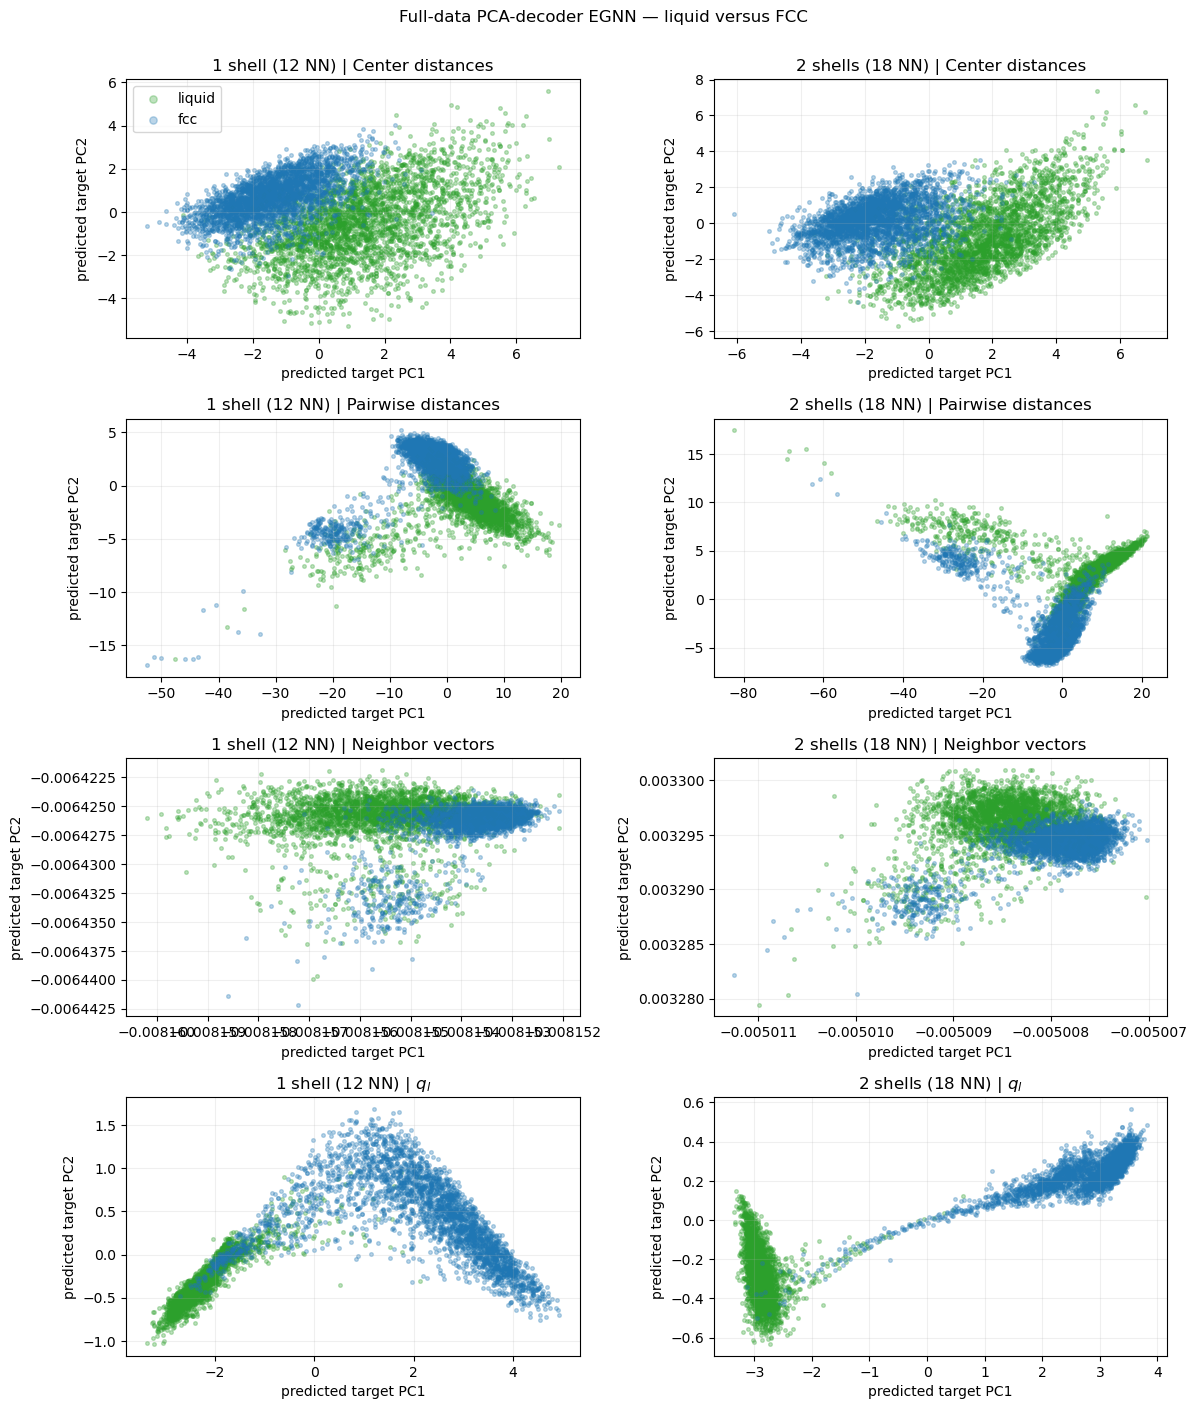

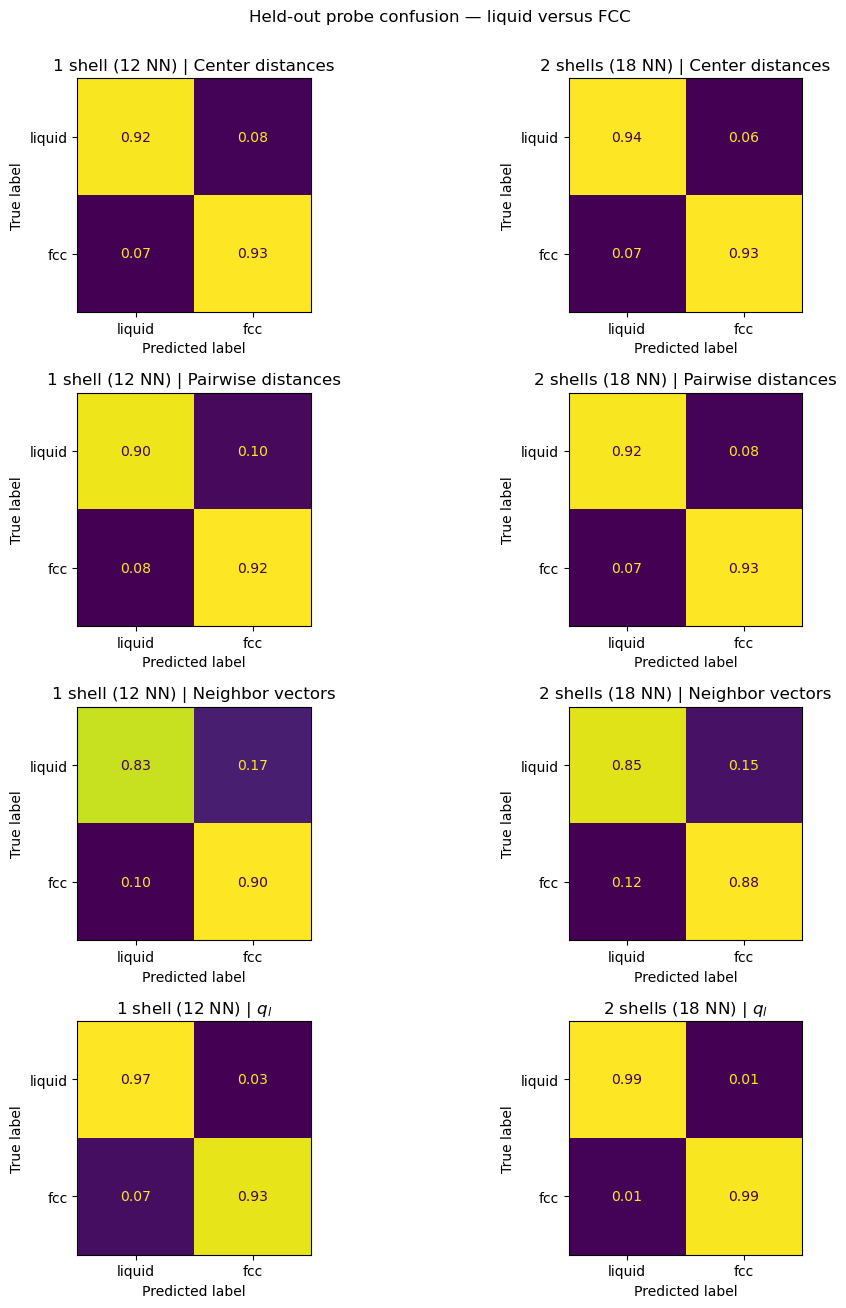

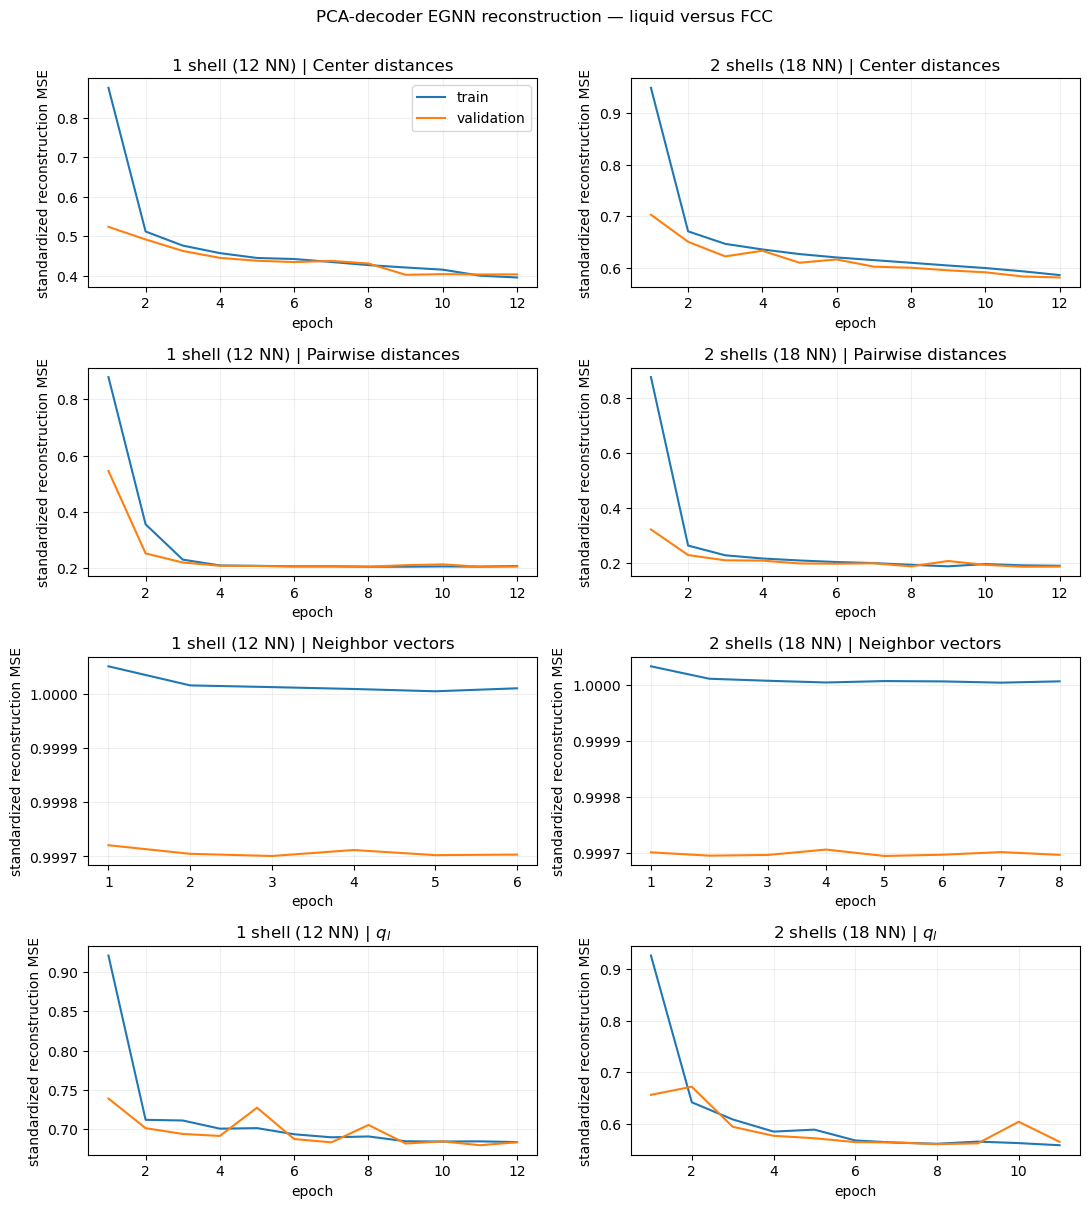

In [16]:
if RUN_FULL_DATASET_PCA_EGNN:
    full_binary_results, full_binary_artifacts, full_binary_plan = (
        run_full_pca_suite(PHASES, LABELS, DATA, FULL_DATA_SEED)
    )
    display(
        full_binary_results[
            [
                "shell_label", "target_label", "n_samples",
                "pca_ceiling_skill", "reconstruction_skill",
                "fraction_of_pca_ceiling", "PC1_score_R2", "PC2_score_R2",
                "initial_probe_ba", "trained_probe_ba", "probe_ba_gain",
                "latent_total_std", "latent_effective_rank", "best_epoch",
            ]
        ].round(4)
    )
    plot_full_latents(
        full_binary_artifacts,
        PHASES,
        LABELS,
        COLORS,
        "Full-data PCA-decoder EGNN — liquid versus FCC",
    )
    plot_full_confusions(
        full_binary_artifacts,
        PHASES,
        LABELS,
        "Held-out probe confusion — liquid versus FCC",
    )
    plot_full_training(
        full_binary_artifacts,
        "PCA-decoder EGNN reconstruction — liquid versus FCC",
    )

### Full-data liquid versus FCC versus HCP

The same fixed-PCA-decoder experiment is repeated with all three phases. A useful two-dimensional result should recover both PCA scores and improve FCC/HCP recall, rather than merely separating liquid from a combined crystalline group.

PCA-EGNN | liquid/fcc/hcp | 1 shell (12 NN) | Center distances
epoch=01 train_mse=0.75884 val_mse=0.50453
epoch=02 train_mse=0.48512 val_mse=0.46388
epoch=03 train_mse=0.46392 val_mse=0.45635
epoch=04 train_mse=0.44984 val_mse=0.44338
epoch=05 train_mse=0.43624 val_mse=0.42979
epoch=06 train_mse=0.42765 val_mse=0.42023
epoch=07 train_mse=0.41942 val_mse=0.43048
epoch=08 train_mse=0.41288 val_mse=0.41124
epoch=09 train_mse=0.40745 val_mse=0.40340
epoch=10 train_mse=0.40213 val_mse=0.39980
epoch=11 train_mse=0.39764 val_mse=0.38518
epoch=12 train_mse=0.39261 val_mse=0.39208
PCA-EGNN | liquid/fcc/hcp | 1 shell (12 NN) | Pairwise distances
epoch=01 train_mse=0.67368 val_mse=0.23542
epoch=02 train_mse=0.23306 val_mse=0.23076
epoch=03 train_mse=0.21453 val_mse=0.21309
epoch=04 train_mse=0.21199 val_mse=0.21194
epoch=05 train_mse=0.21198 val_mse=0.21821
epoch=06 train_mse=0.20951 val_mse=0.21272
epoch=07 train_mse=0.20913 val_mse=0.21073
epoch=08 train_mse=0.20902 val_mse=0.21264
epoch=09 tra

,shell_label,target_label,n_samples,pca_ceiling_skill,reconstruction_skill,fraction_of_pca_ceiling,PC1_score_R2,PC2_score_R2,initial_probe_ba,trained_probe_ba,probe_ba_gain,latent_total_std,latent_effective_rank,best_epoch
0,1 shell (12 NN),Center distances,270900,0.7004,0.6132,0.8754,0.8936,0.8467,0.5105,0.6436,0.1332,2.6428,1.8456,11
1,1 shell (12 NN),Pairwise distances,270900,0.8140,0.7948,0.9764,0.9909,0.8927,0.5104,0.6155,0.1051,7.7264,1.2992,12
2,1 shell (12 NN),Neighbor vectors,270900,0.0785,-0.0000,-0.0001,-0.0000,-0.0002,0.5106,0.5268,0.0162,0.0000,1.2749,3
3,1 shell (12 NN),$q_l$,270900,0.4954,0.2250,0.4543,0.5673,0.1601,0.5103,0.6353,0.1250,2.2456,1.0606,5
4,2 shells (18 NN),Center distances,270900,0.5091,0.4037,0.7928,0.8997,0.6302,0.7037,0.6197,-0.0840,2.6505,1.7539,11
5,2 shells (18 NN),Pairwise distances,270900,0.8290,0.8030,0.9687,0.9870,0.8276,0.7036,0.6284,-0.0752,11.6226,1.2110,9
6,2 shells (18 NN),Neighbor vectors,270900,0.0634,-0.0000,-0.0000,-0.0000,-0.0001,0.7035,0.6230,-0.0805,0.0000,1.3470,1
7,2 shells (18 NN),$q_l$,270900,0.6397,0.3938,0.6155,0.8141,0.0444,0.7037,0.8072,0.1036,2.7609,1.0129,6


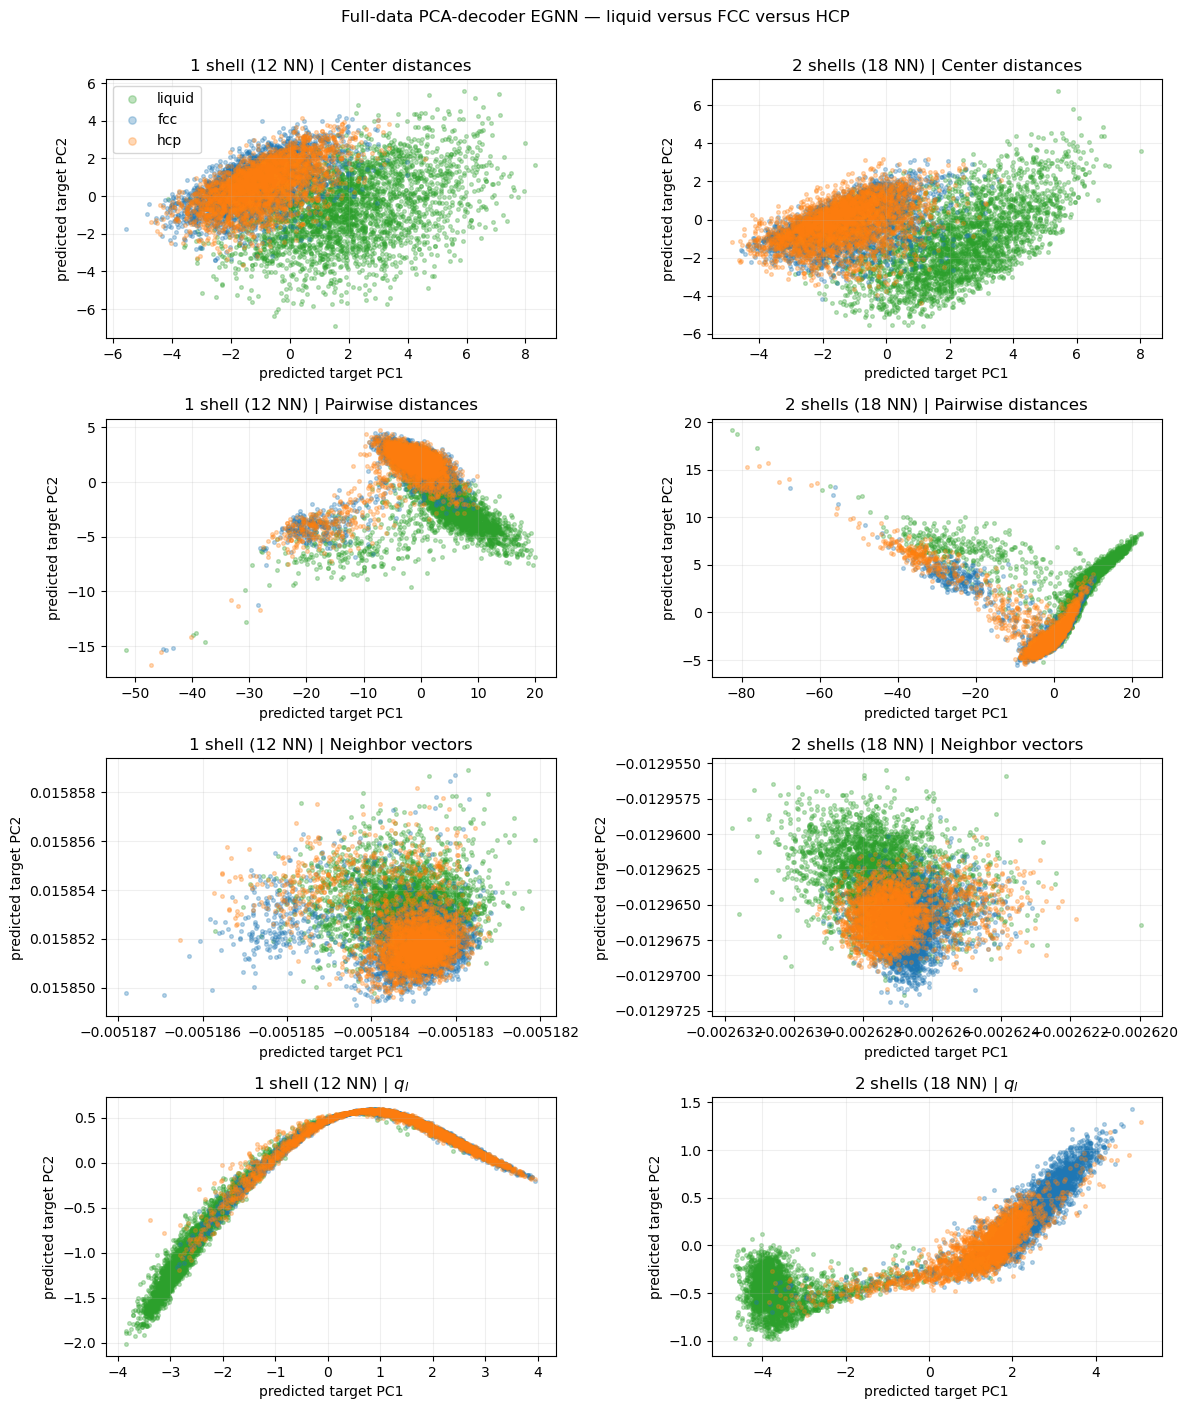

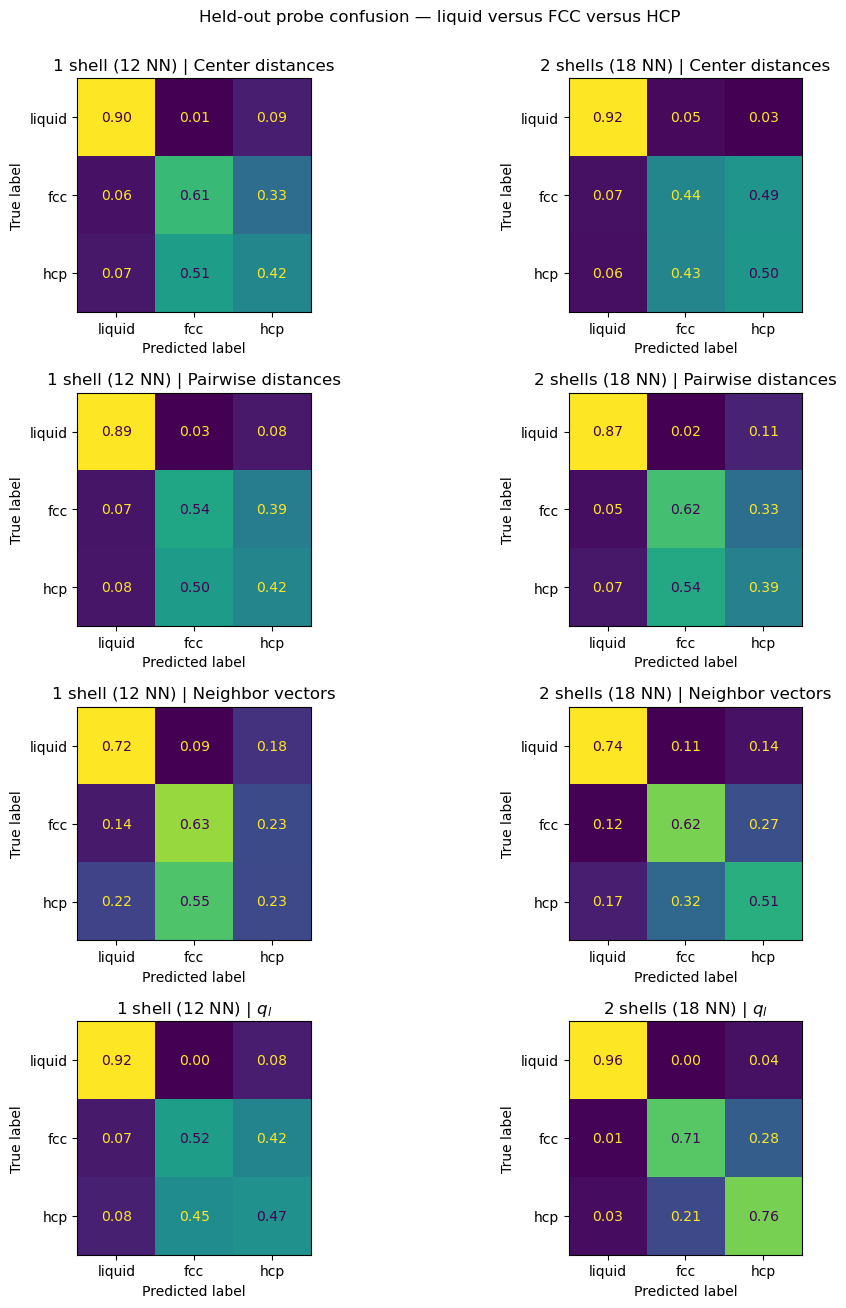

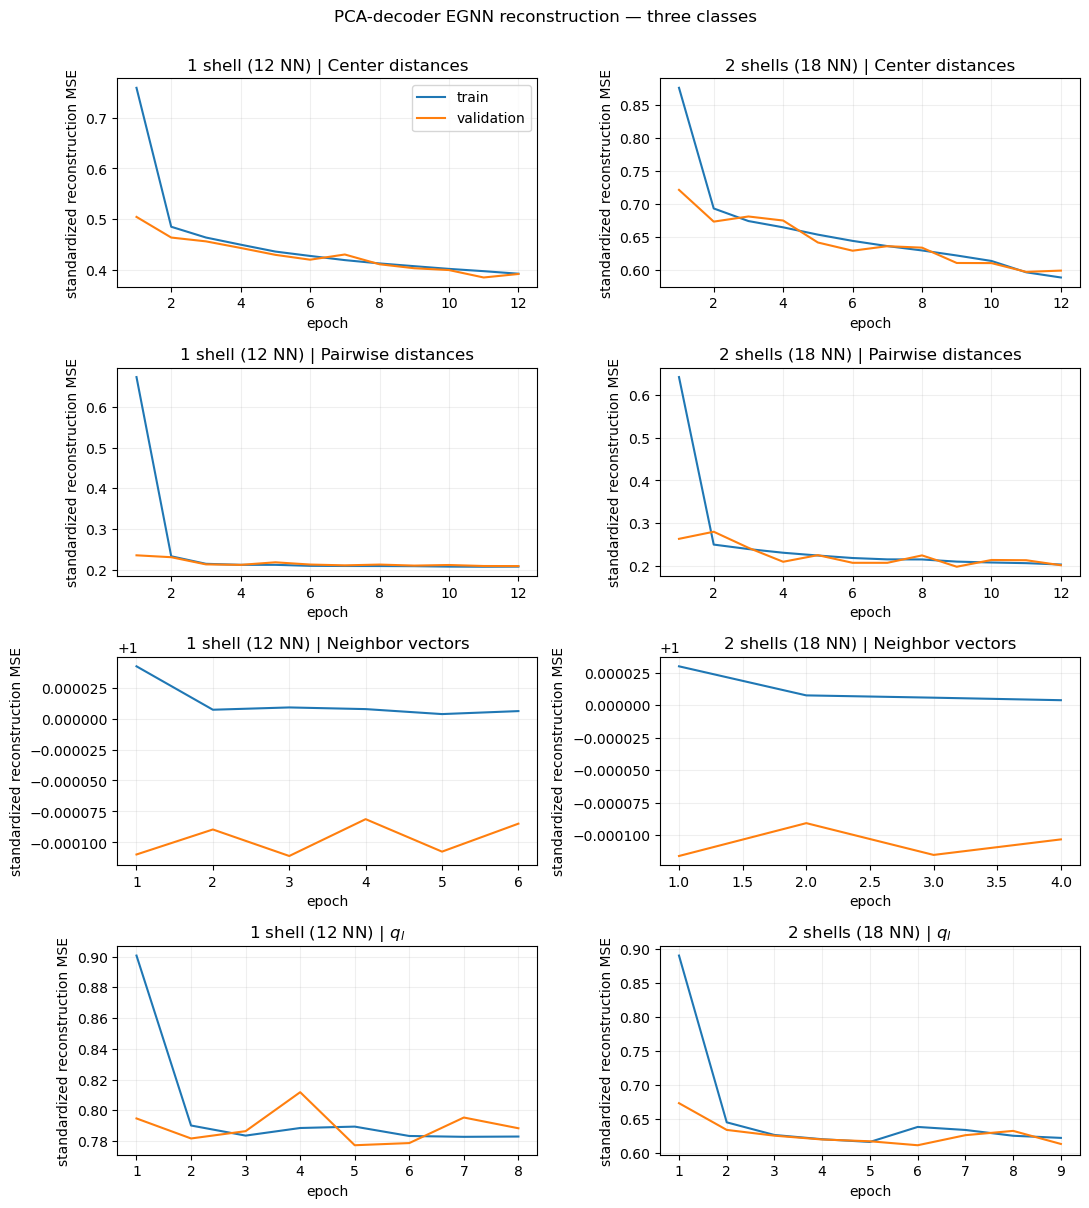

In [17]:
if RUN_FULL_DATASET_PCA_EGNN:
    full_three_results, full_three_artifacts, full_three_plan = (
        run_full_pca_suite(
            THREE_PHASES,
            THREE_LABELS,
            THREE_DATA,
            FULL_DATA_SEED,
        )
    )
    display(
        full_three_results[
            [
                "shell_label", "target_label", "n_samples",
                "pca_ceiling_skill", "reconstruction_skill",
                "fraction_of_pca_ceiling", "PC1_score_R2", "PC2_score_R2",
                "initial_probe_ba", "trained_probe_ba", "probe_ba_gain",
                "latent_total_std", "latent_effective_rank", "best_epoch",
            ]
        ].round(4)
    )
    plot_full_latents(
        full_three_artifacts,
        THREE_PHASES,
        THREE_LABELS,
        THREE_COLORS,
        "Full-data PCA-decoder EGNN — liquid versus FCC versus HCP",
    )
    plot_full_confusions(
        full_three_artifacts,
        THREE_PHASES,
        THREE_LABELS,
        "Held-out probe confusion — liquid versus FCC versus HCP",
    )
    plot_full_training(
        full_three_artifacts,
        "PCA-decoder EGNN reconstruction — three classes",
    )

### Acceptance criteria

The plots are believable only when the numerical checks agree with them. For an invariant target, both PCA-score $R^2$ values should be positive, reconstruction skill should approach the target’s PCA ceiling, and training should outperform the identical untrained encoder. A visually broad latent with poor score prediction is not accepted. Vectors should fail these checks and act as the negative control.

For the three-class result, inspect the normalized confusion matrix directly. Balanced accuracy near $2/3$ can still mean “liquid versus crystal” with FCC and HCP confused. Evidence for useful second-shell structure requires better FCC/HCP recall, not only a prettier cloud.

The second-shell averaged $q_l$ result remains provisional because the checked-in descriptor was averaged with 12 neighbors even though the graph contains 18 geometric neighbors.